# 6. Análisis bivariado

Primero se compara cada predictora con la clase de aptitud (Baja, Media, Alta). Después se revisa cómo se relacionan las predictoras entre sí.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils import *

set_style()
np.random.seed(SEED)
df = load_data()

## 6.1 Predictoras frente a la clase

En el título de cada gráfico va el ε² de Kruskal-Wallis: la parte de la variación de la predictora que explica la clase.

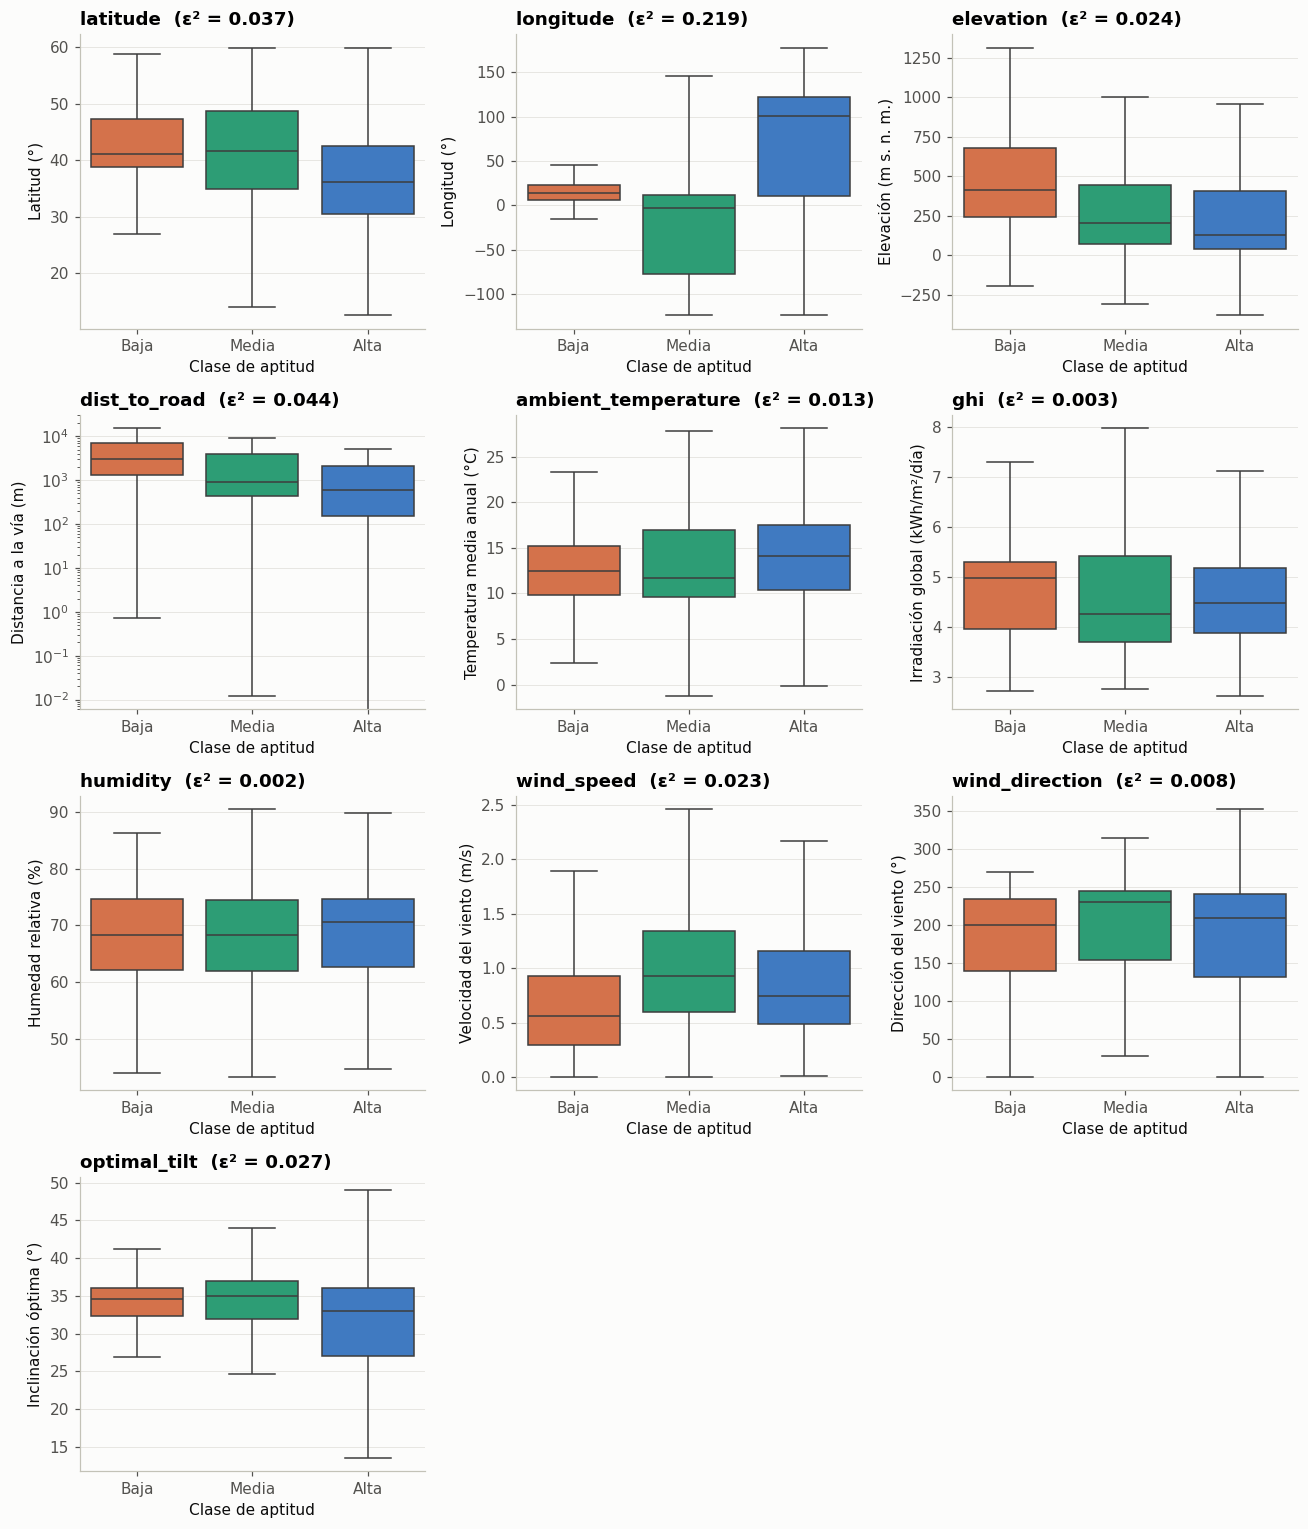

In [2]:
fig, axes = plt.subplots(4, 3, figsize=(12, 14))
for ax, col in zip(axes.flat, NUMERIC):
    sns.boxplot(data=df, x=TARGET, y=col, order=CLASS_ORDER, hue=TARGET,
                palette=CLASS_COLORS, legend=False, showfliers=False, ax=ax)
    if col == "dist_to_road":
        ax.set_yscale("log")
    eps = kruskal_by_class(df, col)["epsilon2"]
    ax.set_xlabel("Clase de aptitud"); ax.set_ylabel(AXIS_LABELS[col])
    ax.set_title(f"{col}  (ε² = {eps:.3f})")
for ax in axes.flat[len(NUMERIC):]:
    ax.remove()
fig.tight_layout()
plt.show()

- **`longitude`** es la que más separa (ε² = 0.22).
- **`dist_to_road`** (escala log): las plantas Baja suelen estar más lejos de una vía (3.1 km) que las Media (0.9 km) y las Alta (0.6 km).
- **`elevation`**: la aptitud baja a medida que sube la altura (132 m en Alta, 207 m en Media, 416 m en Baja).
- **`latitude`** y **`optimal_tilt`**: Alta está algo más cerca del Ecuador y por eso su inclinación óptima es un poco menor.
- **`wind_speed`**: Media tiene el viento más fuerte y Baja el más débil. La relación no es uniforme, sube y luego baja.
- **`ambient_temperature`**, **`wind_direction`**, **`ghi`** y **`humidity`** muestran cajas muy parecidas entre clases, por sí solas casi no separan.

## 6.2 Correlación entre predictoras

Se compara cada predictora con las demás para analizar las variables redundantes. Se usa la correlación de **Spearman**.

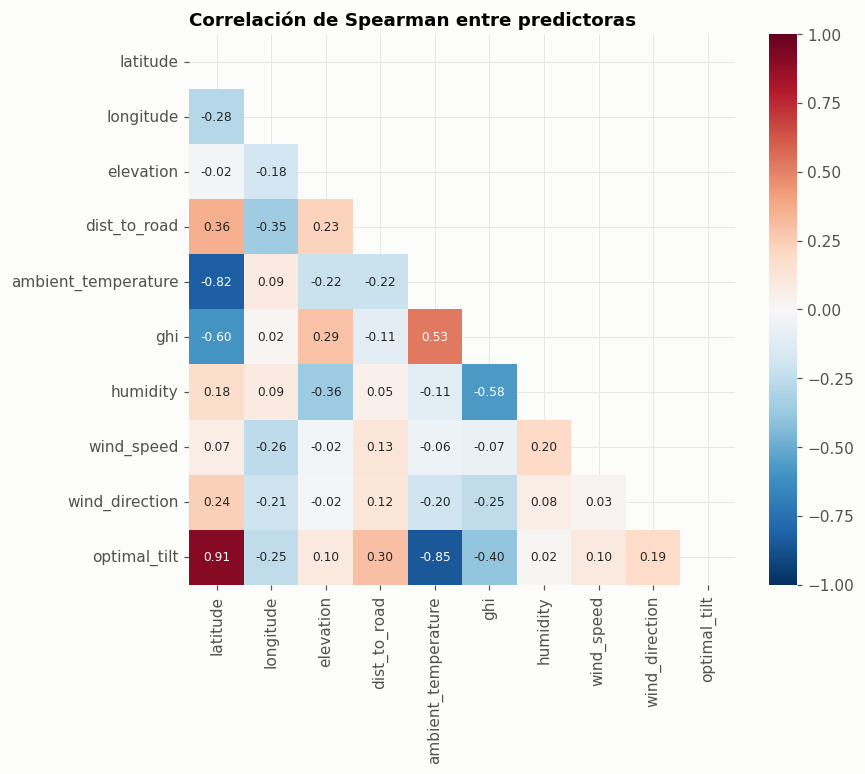

In [3]:
corr = df[NUMERIC].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), cmap="RdBu_r",
            vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 8}, ax=ax)
ax.set_title("Correlación de Spearman entre predictoras")
plt.show()

- Hay un **bloque de tres variables redundantes**: `latitude` y `optimal_tilt` (ρ = 0.91), `optimal_tilt` y `ambient_temperature` (−0.85), y `latitude` y `ambient_temperature` (−0.82).
- Le siguen relaciones moderadas entre las variables climáticas: `latitude` con `ghi` (−0.60), `ghi` con `humidity` (−0.58) y `ambient_temperature` con `ghi` (0.53).

Para la regresión logística esta colinealidad infla la varianza de los coeficientes. Conviene probar el modelo sin `optimal_tilt` o con regularización;